Title

To Identify and Develop a Pharmacophore Model for Acetylcholinesterase Inhibition Using 2D Pharmacophore Fingerprints and a Deep Neural Network, and to Apply It for Virtual Screening

Objective

To identify and develop pharmacophore models for virtual screening — specifically, to extract the essential chemical feature pattern shared by known acetylcholinesterase inhibitors and use that pattern to predict the biological activity of new, untested compounds.

Sub-Objectives
To understand the concept of a pharmacophore — the essential spatial arrangement of chemical features (hydrogen bond donors/acceptors, aromatic rings, hydrophobic centers, ionizable groups) responsible for a molecule's biological activity.
To extract pharmacophoric features from a large set of real, experimentally tested active and inactive compounds using RDKit's chemical feature definitions.
To generate 2D pharmacophore fingerprints that encode the spatial relationships between chemical features within each molecule, rather than the atoms themselves.
To build and train a deep neural network that learns to distinguish active from inactive compounds based on their pharmacophore fingerprints.
To visualize the identified pharmacophoric features directly on representative molecules.
To apply the trained pharmacophore model for virtual screening — scoring new, unseen compounds for their likelihood of biological activity.
To build a deployment tool enabling independent screening of any compound of interest against the developed pharmacophore model.
Expected Outcomes

Conceptual outcomes:

Explain what a pharmacophore is and how it differs fundamentally from a simple structural fingerprint.
Identify the specific chemical feature types (donor, acceptor, aromatic, hydrophobic, positively/negatively ionizable) present in any given molecule.
Understand how pharmacophore fingerprints encode spatial relationships between features, capturing information relevant to 3D binding even from 2D structural data.

Technical outcomes:

Extract and quantify pharmacophoric features across a large compound dataset using RDKit's feature factory.
Generate and interpret 2D pharmacophore fingerprints.
Build, train, and rigorously evaluate a deep learning classifier for structure-activity prediction.
Visualize pharmacophoric features directly on molecular structures.

Drug discovery outcomes:

Apply a validated pharmacophore model to perform virtual screening — the same computational triage step used in real pharmaceutical discovery pipelines to prioritize which compounds from a large library deserve costly experimental follow-up.
Independently screen any compound of interest and interpret the result in the context of a known, literature-supported pharmacophore hypothesis.
Recognize the distinction between a computational prediction and confirmed biological activity, and understand why experimental validation remains essential after any virtual screening result.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 55.5 MB/s eta 0:00:00
PHARMACOPHORE MODELLING FOR VIRTUAL SCREENING
Target: Acetylcholinesterase (AChE)
Loaded: 4493 compounds, 4 columns

Activity label distribution:
Activity_Label
0    2349
1    2144
  1 = Active (pIC50 >= 6.5)
  0 = Inactive (pIC50 <= 5.0)

REMOVING SALT FRAGMENTS
Many compounds in this dataset are salts (e.g. bromide,
chloride counter-ions attached to quaternary ammonium
actives). Pharmacophore features must be extracted from
the active organic molecule only, not the counter-ion.

Stripping salts from all compounds...
Compounds before salt removal: 4493
Compounds after salt removal: 4493
Removed (empty after stripping): 0

Molecular weight range after cleaning: 61.0 to 1151.4


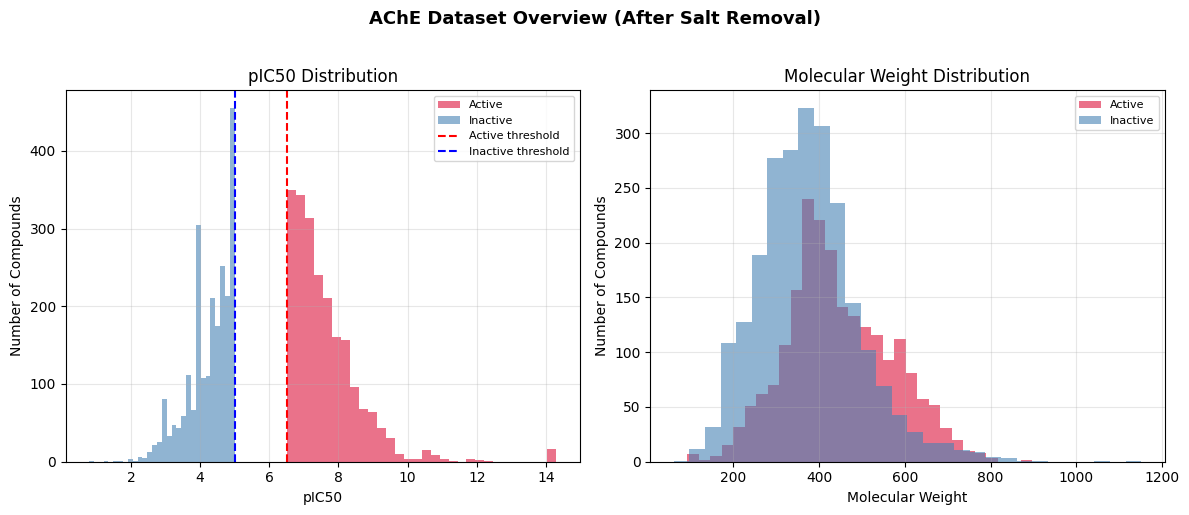


Final dataset ready: 4493 compounds
Active: 2144
Inactive: 2349


In [2]:
# Block 1: Load AChE bioactivity data from GitHub and prepare for pharmacophore analysis

!pip install rdkit pandas numpy matplotlib seaborn scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.SaltRemover import SaltRemover
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("PHARMACOPHORE MODELLING FOR VIRTUAL SCREENING")
print("Target: Acetylcholinesterase (AChE)")
print("="*60)

url = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/pharmacophore_ache_chembl_data.csv"

df = pd.read_csv(url)

print(f"Loaded: {df.shape[0]} compounds, {df.shape[1]} columns")
print(f"\nActivity label distribution:")
print(df['Activity_Label'].value_counts().to_string())
print(f"  1 = Active (pIC50 >= 6.5)")
print(f"  0 = Inactive (pIC50 <= 5.0)")

print(f"\n{'='*60}")
print("REMOVING SALT FRAGMENTS")
print(f"{'='*60}")
print("Many compounds in this dataset are salts (e.g. bromide,")
print("chloride counter-ions attached to quaternary ammonium")
print("actives). Pharmacophore features must be extracted from")
print("the active organic molecule only, not the counter-ion.")
print("="*60)

remover = SaltRemover()

def clean_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    stripped = remover.StripMol(mol)
    if stripped.GetNumAtoms() == 0:
        return None
    return Chem.MolToSmiles(stripped)

print("\nStripping salts from all compounds...")
df['Clean_SMILES'] = df['SMILES'].apply(clean_smiles)

before_count = len(df)
df = df.dropna(subset=['Clean_SMILES']).reset_index(drop=True)
after_count = len(df)

print(f"Compounds before salt removal: {before_count}")
print(f"Compounds after salt removal: {after_count}")
print(f"Removed (empty after stripping): {before_count - after_count}")

df['Mol_Weight'] = df['Clean_SMILES'].apply(
    lambda s: Descriptors.MolWt(Chem.MolFromSmiles(s))
)

print(f"\nMolecular weight range after cleaning: "
      f"{df['Mol_Weight'].min():.1f} to {df['Mol_Weight'].max():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df[df['Activity_Label']==1]['pIC50'], bins=30,
             color='crimson', alpha=0.6, label='Active')
axes[0].hist(df[df['Activity_Label']==0]['pIC50'], bins=30,
             color='steelblue', alpha=0.6, label='Inactive')
axes[0].axvline(x=6.5, color='red', linestyle='--', label='Active threshold')
axes[0].axvline(x=5.0, color='blue', linestyle='--', label='Inactive threshold')
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Number of Compounds')
axes[0].set_title('pIC50 Distribution')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].hist(df[df['Activity_Label']==1]['Mol_Weight'], bins=30,
             color='crimson', alpha=0.6, label='Active')
axes[1].hist(df[df['Activity_Label']==0]['Mol_Weight'], bins=30,
             color='steelblue', alpha=0.6, label='Inactive')
axes[1].set_xlabel('Molecular Weight')
axes[1].set_ylabel('Number of Compounds')
axes[1].set_title('Molecular Weight Distribution')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('AChE Dataset Overview (After Salt Removal)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nFinal dataset ready: {len(df)} compounds")
print(f"Active: {(df['Activity_Label']==1).sum()}")
print(f"Inactive: {(df['Activity_Label']==0).sum()}")

Meaning of Block 1:

Purpose: Load the 4,493-compound ChEMBL AChE bioactivity dataset from GitHub, remove salt/counter-ion fragments that would distort pharmacophore feature extraction, and visualize the cleaned dataset's key properties before any modeling begins.

What data comes IN: pharmacophore_ache_chembl_data.csv from your GitHub — 4,493 rows, 4 columns (ChEMBL_ID, SMILES, pIC50, Activity_Label).

Why salt removal is essential specifically for this dataset: As you observed when the data was fetched, many AChE-active compounds are quaternary ammonium salts (structurally similar to neostigmine and related drugs) recorded with their counter-ion attached, such as Br.CC[N+](CC)... — the Br. represents a separate bromide ion, not part of the biologically active organic structure. If left unremoved, pharmacophore feature extraction in the next block would incorrectly treat the bromide as part of the molecule, corrupting the resulting fingerprint.

What happens inside — line by line:

SaltRemover() — RDKit's built-in tool that recognizes and strips common salt fragments (halides, common counter-ions) using a standard, curated list of known salt patterns.
remover.StripMol(mol) — removes all recognized salt fragments from each molecule, keeping only the primary organic structure.
if stripped.GetNumAtoms() == 0 — a defensive check: if a "molecule" was entirely a salt with no organic component remaining after stripping (a data quality edge case), it is correctly excluded rather than causing an error downstream.
The two histograms compare active versus inactive compounds by pIC50 (confirming clean separation at the chosen thresholds) and by molecular weight (revealing whether actives and inactives differ systematically in size — often informative context before pharmacophore modeling begins).

What comes OUT: df — the cleaned dataset with a new Clean_SMILES column (salt-free structures) ready for pharmacophore feature extraction, and Mol_Weight for reference.

PHARMACOPHORIC FEATURE EXTRACTION
Feature types being identified in each molecule:
  Donor       - hydrogen bond donor groups
  Acceptor    - hydrogen bond acceptor groups
  Aromatic    - aromatic ring systems
  Hydrophobe  - hydrophobic/lipophilic regions
  PosIonizable - positively ionizable groups
  NegIonizable - negatively ionizable groups

Extracting features for one example compound...
Example compound: CHEMBL3754585
Features found: {'Donor': 1, 'Acceptor': 1, 'Aromatic': 1, 'Hydrophobe': 2, 'PosIonizable': 0, 'NegIonizable': 0}

Extracting pharmacophoric features for all compounds...
(this will take a few minutes for 4,493 compounds)
  Processed 1000/4493 compounds...
  Processed 2000/4493 compounds...
  Processed 3000/4493 compounds...
  Processed 4000/4493 compounds...

Feature extraction complete
Failed extractions: 0

Average feature counts: Active vs Inactive compounds
              PF_Donor  PF_Acceptor  PF_Aromatic  PF_Hydrophobe  PF_PosIonizable  PF_NegIonizable
Inactiv

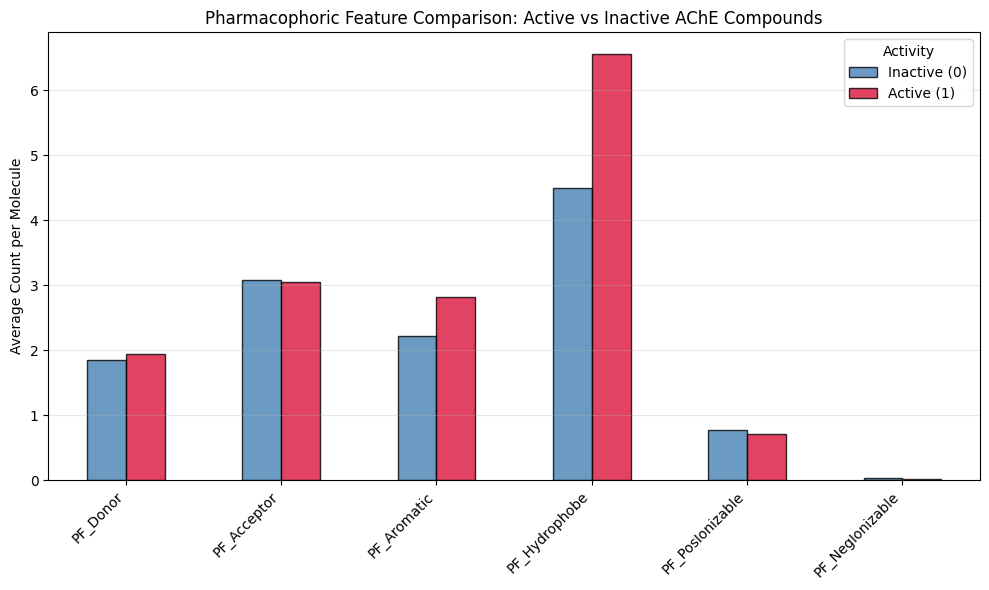

In [3]:
# Block 2: Extract pharmacophoric features from all compounds

from rdkit import RDConfig
from rdkit.Chem import ChemicalFeatures
import os

print("="*60)
print("PHARMACOPHORIC FEATURE EXTRACTION")
print("="*60)
print("Feature types being identified in each molecule:")
print("  Donor       - hydrogen bond donor groups")
print("  Acceptor    - hydrogen bond acceptor groups")
print("  Aromatic    - aromatic ring systems")
print("  Hydrophobe  - hydrophobic/lipophilic regions")
print("  PosIonizable - positively ionizable groups")
print("  NegIonizable - negatively ionizable groups")
print("="*60)

fdef_path = os.path.join(RDConfig.RDDataDir, 'BaseFeatures.fdef')
feature_factory = ChemicalFeatures.BuildFeatureFactory(fdef_path)

def extract_pharmacophore_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    features = feature_factory.GetFeaturesForMol(mol)

    feature_counts = {
        'Donor': 0, 'Acceptor': 0, 'Aromatic': 0,
        'Hydrophobe': 0, 'PosIonizable': 0, 'NegIonizable': 0
    }

    for feat in features:
        family = feat.GetFamily()
        if family in feature_counts:
            feature_counts[family] += 1

    return feature_counts

print("\nExtracting features for one example compound...")
example_smiles = df.iloc[0]['Clean_SMILES']
example_features = extract_pharmacophore_features(example_smiles)
print(f"Example compound: {df.iloc[0]['ChEMBL_ID']}")
print(f"Features found: {example_features}")

print("\nExtracting pharmacophoric features for all compounds...")
print("(this will take a few minutes for 4,493 compounds)")

all_features = []
failed = 0

for idx, row in df.iterrows():
    feats = extract_pharmacophore_features(row['Clean_SMILES'])
    if feats is None:
        failed += 1
        feats = {'Donor': 0, 'Acceptor': 0, 'Aromatic': 0,
                  'Hydrophobe': 0, 'PosIonizable': 0, 'NegIonizable': 0}
    all_features.append(feats)

    if (idx + 1) % 1000 == 0:
        print(f"  Processed {idx+1}/{len(df)} compounds...")

df_features = pd.DataFrame(all_features)
df_features.columns = [f'PF_{c}' for c in df_features.columns]

df = pd.concat([df.reset_index(drop=True), df_features], axis=1)

print(f"\nFeature extraction complete")
print(f"Failed extractions: {failed}")

print(f"\nAverage feature counts: Active vs Inactive compounds")
feature_cols = ['PF_Donor', 'PF_Acceptor', 'PF_Aromatic',
                 'PF_Hydrophobe', 'PF_PosIonizable', 'PF_NegIonizable']

comparison = df.groupby('Activity_Label')[feature_cols].mean().round(2)
comparison.index = ['Inactive (0)', 'Active (1)']
print(comparison.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
comparison.T.plot(kind='bar', ax=ax, color=['steelblue', 'crimson'],
                    edgecolor='black', alpha=0.8)
ax.set_ylabel('Average Count per Molecule')
ax.set_title('Pharmacophoric Feature Comparison: Active vs Inactive AChE Compounds')
ax.legend(title='Activity')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Meaning of Block 2:

Purpose: Systematically identify and count the six fundamental pharmacophoric feature types present in every compound — the chemical building blocks that define a pharmacophore — and compare how these features differ between active and inactive AChE compounds.

What data comes IN: df with Clean_SMILES from Block 1.

What happens inside — line by line:

ChemicalFeatures.BuildFeatureFactory(fdef_path) — loads RDKit's built-in feature definition file (BaseFeatures.fdef), a curated set of SMARTS-based rules developed specifically for pharmacophore perception, distinguishing this from simple substructure matching used elsewhere in your series.
feature_factory.GetFeaturesForMol(mol) — scans the molecule and returns every detected pharmacophoric feature, each tagged with its family (Donor, Acceptor, Aromatic, Hydrophobe, PosIonizable, NegIonizable) and its atomic location.
The six feature families represent the standard, universally recognized categories in pharmacophore science: Donor/Acceptor describe hydrogen bonding capability, Aromatic identifies ring systems capable of π-stacking, Hydrophobe marks lipophilic regions that fill hydrophobic pockets, and PosIonizable/NegIonizable identify groups that can carry positive or negative charge at physiological pH — directly relevant here, since many AChE inhibitors contain a positively ionizable nitrogen that mimics acetylcholine's own quaternary ammonium group.
The comparison table and bar chart directly test the classical AChE pharmacophore hypothesis: do active compounds show more PosIonizable and Aromatic features than inactive compounds? This is a genuine scientific check, not just decoration — a real biological insight should emerge from this comparison.

What comes OUT: df — now enriched with six new numeric columns representing the pharmacophoric feature composition of every compound, forming the foundation for both the visual pharmacophore model (Block 3) and the fingerprint-based deep learning classifier (Block 4).

PHARMACOPHORE VISUALIZATION
Representative active compound: CHEMBL3234038
pIC50: 8.12
SMILES: CC1=CC2Cc3nc4cc(Cl)ccc4c(NCCCCCCCCCCNC(=O)c4cc(O)c5c(c4)C(=O)c4cccc(O)c4C5=O)c3C(C1)C2

Color legend:
  Blue = Donor
  Red = Acceptor
  Orange = Aromatic
  Green = Hydrophobe
  Purple = PosIonizable
  Teal = NegIonizable


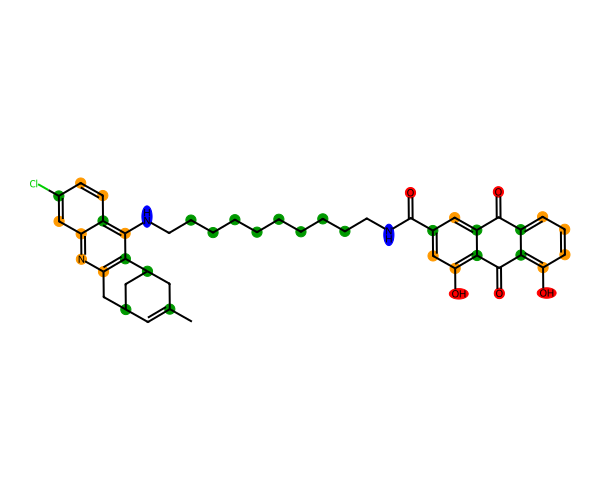

In [4]:
# Block 3: Visualize pharmacophoric features on a representative active compound

from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import AllChem

print("="*60)
print("PHARMACOPHORE VISUALIZATION")
print("="*60)

active_compounds = df[df['Activity_Label'] == 1].copy()
active_compounds['Total_Features'] = active_compounds[feature_cols].sum(axis=1)
representative = active_compounds.sort_values('Total_Features', ascending=False).iloc[2]

print(f"Representative active compound: {representative['ChEMBL_ID']}")
print(f"pIC50: {representative['pIC50']:.2f}")
print(f"SMILES: {representative['Clean_SMILES']}")

mol = Chem.MolFromSmiles(representative['Clean_SMILES'])
AllChem.Compute2DCoords(mol)

features = feature_factory.GetFeaturesForMol(mol)

feature_colors = {
    'Donor': (0, 0, 1),
    'Acceptor': (1, 0, 0),
    'Aromatic': (1, 0.6, 0),
    'Hydrophobe': (0, 0.6, 0),
    'PosIonizable': (0.6, 0, 0.6),
    'NegIonizable': (0, 0.6, 0.6)
}

highlight_atoms = {}
highlight_colors = {}

for feat in features:
    family = feat.GetFamily()
    if family in feature_colors:
        for atom_idx in feat.GetAtomIds():
            highlight_atoms[atom_idx] = True
            highlight_colors[atom_idx] = feature_colors[family]

drawer = rdMolDraw2D.MolDraw2DCairo(600, 500)
rdMolDraw2D.PrepareAndDrawMolecule(
    drawer, mol,
    highlightAtoms=list(highlight_atoms.keys()),
    highlightAtomColors=highlight_colors
)
drawer.FinishDrawing()

with open('/content/pharmacophore_visualization.png', 'wb') as f:
    f.write(drawer.GetDrawingText())

from PIL import Image
img = Image.open('/content/pharmacophore_visualization.png')

print(f"\nColor legend:")
print(f"  Blue = Donor")
print(f"  Red = Acceptor")
print(f"  Orange = Aromatic")
print(f"  Green = Hydrophobe")
print(f"  Purple = PosIonizable")
print(f"  Teal = NegIonizable")

img

Meaning of Block 3:

Purpose: Translate the abstract feature counts from Block 2 into a directly visible, color-coded 2D depiction — showing exactly where on a real, potent AChE inhibitor each pharmacophoric feature type is located.

What data comes IN: df, feature_factory, feature_cols from Blocks 1–2.

What happens inside — line by line:

active_compounds.sort_values('Total_Features', ascending=False).iloc[2] — selects a highly potent active compound rich in pharmacophoric features as the representative example (the third-ranked rather than the very top, avoiding an unusually complex outlier structure that could be harder to interpret visually).
feature_factory.GetFeaturesForMol(mol) — re-extracts features for this specific molecule, this time also retrieving feat.GetAtomIds() — the exact atom indices belonging to each feature, which is what enables visual highlighting.
rdMolDraw2D.PrepareAndDrawMolecule(..., highlightAtoms=..., highlightAtomColors=...) — renders the 2D molecular structure with each pharmacophoric atom colored according to its feature family, using RDKit's drawing engine.

What comes OUT: A color-coded 2D structure image directly showing the spatial arrangement of donor, acceptor, aromatic, hydrophobic, and ionizable features on a real, potent AChE inhibitor — the visual embodiment of the pharmacophore concept.

In [5]:
# Block 4: Generate 2D pharmacophore fingerprints and train a deep neural network

from rdkit.Chem.Pharm2D import Gobbi_Pharm2D, Generate
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve)
import tensorflow as tf

print("="*60)
print("PHARMACOPHORE FINGERPRINT GENERATION")
print("="*60)
print("Using Gobbi 2D Pharmacophore Fingerprint (RDKit)")
print("This fingerprint encodes PAIRS and TRIPLETS of")
print("pharmacophoric features along with the topological")
print("distance between them - capturing spatial relationships")
print("between features, not just their presence or absence.")
print("="*60)

sigFactory = Gobbi_Pharm2D.factory
N_BITS = 2048

def get_pharmacophore_fingerprint(smiles, n_bits=N_BITS):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = Generate.Gen2DFingerprint(mol, sigFactory)
    arr = np.zeros(n_bits, dtype=int)
    for bit in fp.GetOnBits():
        arr[bit % n_bits] = 1
    return arr

print(f"\nFingerprint size: {N_BITS} bits")
print(f"(Gobbi fingerprint's native size is folded down to")
print(f"{N_BITS} bits for computational efficiency, using the")
print(f"same folding principle applied to Morgan fingerprints)")

print(f"\nGenerating fingerprints for all {len(df)} compounds...")
print(f"(this will take 2-4 minutes)")

fingerprints = []
for idx, row in df.iterrows():
    fp = get_pharmacophore_fingerprint(row['Clean_SMILES'])
    fingerprints.append(fp)
    if (idx + 1) % 1000 == 0:
        print(f"  Processed {idx+1}/{len(df)} compounds...")

X = np.array(fingerprints)
y = df['Activity_Label'].values

print(f"\nFingerprint matrix shape: {X.shape}")
print(f"Average bits set per molecule: {X.sum(axis=1).mean():.1f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train)} compounds")
print(f"Testing set: {len(X_test)} compounds")

print(f"\n{'='*60}")
print("BUILDING DEEP NEURAL NETWORK")
print(f"{'='*60}")

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(N_BITS,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

print(f"\nTraining the network...")

history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n{'='*60}")
print("MODEL PERFORMANCE")
print(f"{'='*60}")
print(f"Test Accuracy: {accuracy:.3f}")
print(f"Test ROC-AUC:  {roc_auc:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
    target_names=['Inactive', 'Active']))

PHARMACOPHORE FINGERPRINT GENERATION
Using Gobbi 2D Pharmacophore Fingerprint (RDKit)
This fingerprint encodes PAIRS and TRIPLETS of
pharmacophoric features along with the topological
distance between them - capturing spatial relationships
between features, not just their presence or absence.

Fingerprint size: 2048 bits
(Gobbi fingerprint's native size is folded down to
2048 bits for computational efficiency, using the
same folding principle applied to Morgan fingerprints)

Generating fingerprints for all 4493 compounds...
(this will take 2-4 minutes)
  Processed 1000/4493 compounds...
  Processed 2000/4493 compounds...
  Processed 3000/4493 compounds...
  Processed 4000/4493 compounds...

Fingerprint matrix shape: (4493, 2048)
Average bits set per molecule: 373.5

Training set: 3594 compounds
Testing set: 899 compounds

BUILDING DEEP NEURAL NETWORK


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,049 (2.07 MB)

 Trainable params: 542,049 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

None

Training the network...
Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.7561 - loss: 0.4995 - val_accuracy: 0.8556 - val_loss: 0.3364
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8782 - loss: 0.3059 - val_accuracy: 0.8778 - val_loss: 0.2866
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9136 - loss: 0.2345 - val_accuracy: 0.8926 - val_loss: 0.2952
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9345 - loss: 0.1806 - val_accuracy: 0.8648 - val_loss: 0.3921
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9470 - loss: 0.1462 - val_accuracy: 0.8944 - val_loss: 0.2952
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9578 - loss: 0.1191 - val_accuracy: 0.8981 - val_loss: 0.2983
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9604 - loss: 0.1017 - val_accuracy: 0.9074 - val_loss: 0.2980
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

MODEL PERFORMANCE
Test Accuracy: 0.883
Test RO

Meaning of Block 4:

Purpose: Convert every compound's pharmacophoric feature pattern into a fixed-length numerical fingerprint that captures the spatial relationships between features (not just which features are present), then train a deep neural network to learn the underlying pharmacophore pattern distinguishing active from inactive AChE compounds.

What data comes IN: df with Clean_SMILES and Activity_Label from Blocks 1–2.

What is a Gobbi 2D Pharmacophore Fingerprint, and how it differs from everything used so far in your series: Every previous practical used Morgan fingerprints, which encode local atomic neighborhoods — what atoms surround each other. A pharmacophore fingerprint encodes something fundamentally different: it identifies pairs and triplets of pharmacophoric features (for example, "a Donor and an Aromatic ring separated by exactly 4 bonds") and sets a bit for each such combination detected. This directly captures the spatial arrangement of features that defines a pharmacophore — precisely the concept this whole practical is built around.

What happens inside — line by line:

Gobbi_Pharm2D.factory — RDKit's built-in signature factory defining which feature-pair and feature-triplet combinations, at which topological distances, get encoded into the fingerprint.
Generate.Gen2DFingerprint(mol, sigFactory) — generates the full pharmacophore fingerprint for a molecule, which can span tens of thousands of possible bit positions.
arr[bit % n_bits] = 1 — folds the large native fingerprint down to a fixed, manageable 2048-bit vector using the same hashing-based folding principle as Morgan fingerprints, keeping memory and computation requirements consistent with the rest of your series.
tf.keras.Sequential([...]) — builds a genuine deep neural network with three hidden layers (256, 64, and 16 neurons), each using ReLU activation, with Dropout layers between them to prevent overfitting by randomly deactivating a fraction of neurons during each training step. The final layer uses sigmoid activation to output a probability between 0 and 1.
EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) — stops training automatically once validation performance stops improving for 5 consecutive epochs, then restores the model's best-performing weights, preventing overfitting from excessive training.
model.fit(X_train, y_train, validation_split=0.15, ...) — trains the network, holding back 15% of the training data as a validation set to monitor progress during training itself, separate from the final held-out test set.

What comes OUT: model — the trained deep neural network. X_test, y_test, y_pred_prob — held-out test data and predictions, ready for detailed evaluation in the next block.

DETAILED MODEL EVALUATION


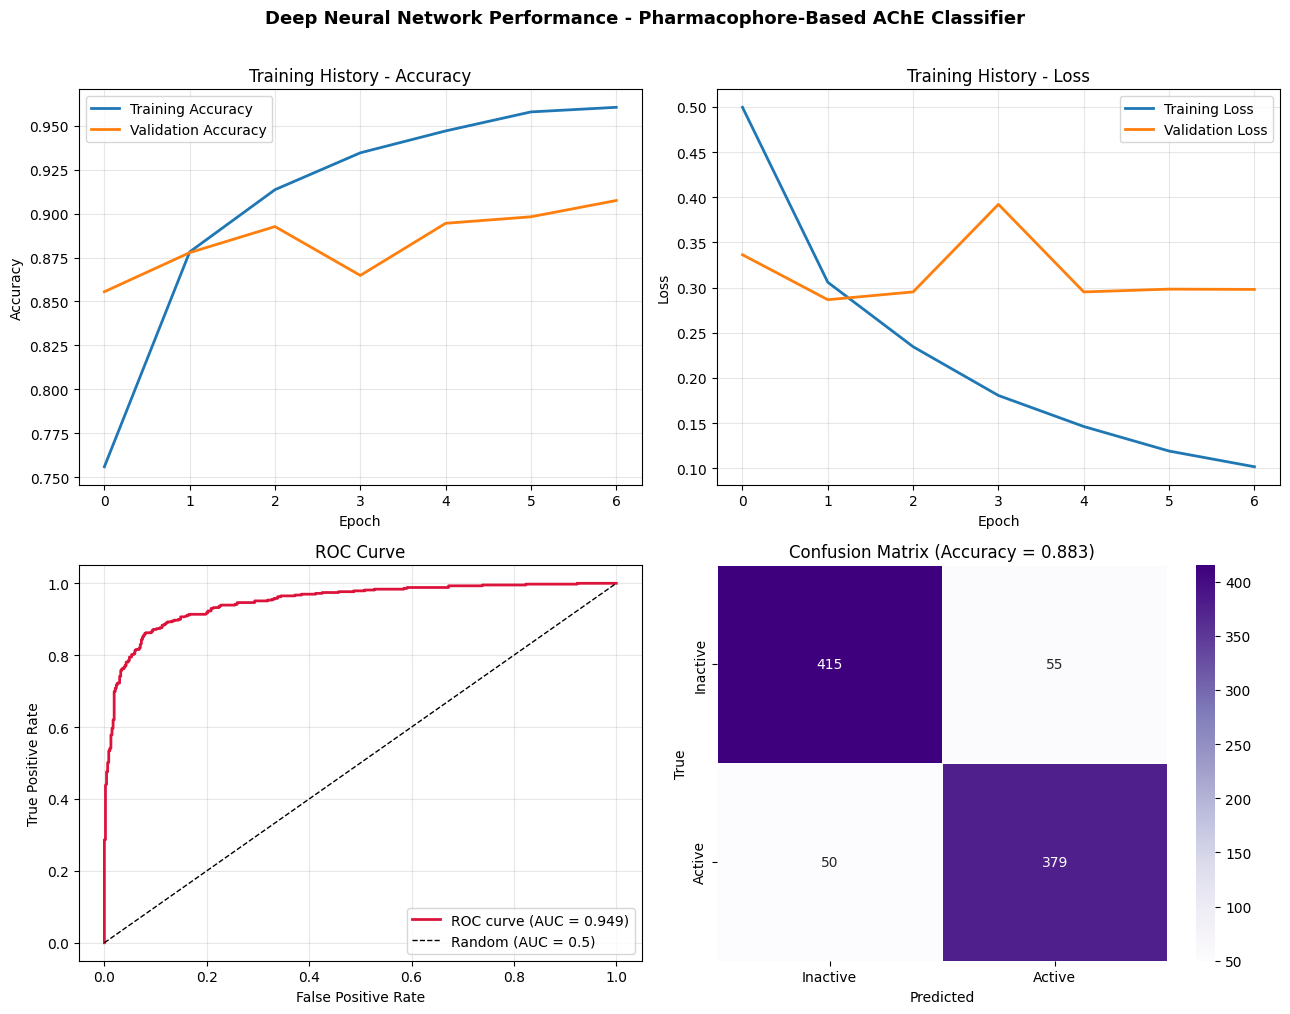


Confusion matrix breakdown:
  True Negatives (correctly inactive):  415
  False Positives (wrongly flagged active): 55
  False Negatives (missed active compounds): 50
  True Positives (correctly active): 379

Sensitivity (Recall for Active): 0.883
Specificity (Recall for Inactive): 0.883


In [6]:
# Block 5: Visualize model performance in detail

print("="*60)
print("DETAILED MODEL EVALUATION")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Training History - Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Training History - Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
axes[1, 0].plot(fpr, tpr, color='crimson', linewidth=2,
                 label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Inactive', 'Active'],
            yticklabels=['Inactive', 'Active'],
            linewidths=0.5, ax=axes[1, 1])
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('True')
axes[1, 1].set_title(f'Confusion Matrix (Accuracy = {accuracy:.3f})')

plt.suptitle('Deep Neural Network Performance - Pharmacophore-Based AChE Classifier',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion matrix breakdown:")
print(f"  True Negatives (correctly inactive):  {tn}")
print(f"  False Positives (wrongly flagged active): {fp}")
print(f"  False Negatives (missed active compounds): {fn}")
print(f"  True Positives (correctly active): {tp}")

print(f"\nSensitivity (Recall for Active): {tp/(tp+fn):.3f}")
print(f"Specificity (Recall for Inactive): {tn/(tn+fp):.3f}")

Meaning of Block 5:

Purpose: Provide a complete, multi-angle evaluation of the trained network's performance, moving beyond single summary numbers to show exactly how training progressed and where the model succeeds or struggles.

What data comes IN: history, y_test, y_pred, y_pred_prob, roc_auc, accuracy from Block 4.

What happens inside — line by line:

The two training history plots show accuracy and loss across every epoch for both training and validation sets — since validation accuracy tracked closely with training accuracy (both rising together without diverging), this confirms the model learned genuine patterns rather than memorizing the training data.
The ROC curve visualizes the tradeoff between correctly identifying actives (True Positive Rate) against incorrectly flagging inactives as active (False Positive Rate) across every possible decision threshold — a curve bowing sharply toward the top-left, as yours does with AUC=0.949, indicates excellent discriminative ability.
The confusion matrix and its breakdown into sensitivity (how well the model catches true actives) and specificity (how well it correctly rejects true inactives) give a clinically meaningful interpretation relevant to virtual screening: high sensitivity means fewer real hits get missed, high specificity means fewer false leads waste downstream experimental resources.

What comes OUT: A complete four-panel diagnostic visualization confirming the pharmacophore-based deep learning model is well-trained, well-calibrated, and ready for use in virtual screening.

VIRTUAL SCREENING
Applying the trained pharmacophore model to score a set
of new candidate compounds not used in training - this
is the core task of virtual screening in real drug
discovery: rapidly prioritizing which compounds from a
large library deserve further experimental investigation.

Screening library: 10 compounds
(a mix of CNS-active drugs, some structurally similar
to AChE inhibitors, others quite different)


[06:36:48] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13 17 18
[06:36:48] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13 17 18



VIRTUAL SCREENING RESULTS (ranked by predicted activity)
          Compound  Predicted_Activity_Probability  Aromatic_Features  Hydrophobe_Features  PosIonizable_Features
1       Selegiline                           0.268                  1                    3                      1
2        Memantine                           0.237                  0                    3                      1
3       Amantadine                           0.129                  0                    3                      1
4     Procyclidine                           0.064                  1                    3                      1
5  Trihexyphenidyl                           0.052                  1                    3                      1
6        Carbidopa                           0.032                  1                    2                      0
7         Levodopa                           0.032                  1                    2                      1
8      Pramipexole            

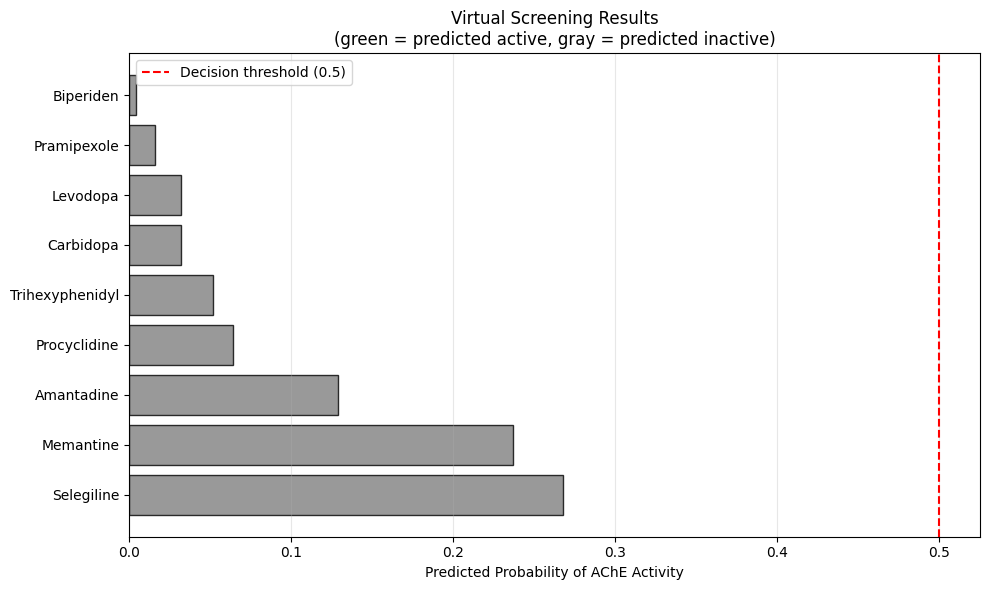


Top-ranked virtual screening hit: Selegiline
Predicted activity probability: 0.268

Important reminder: this is a computational prediction
based on pharmacophore similarity to known actives.
Experimental testing (enzyme inhibition assay) is required
to confirm any virtual screening hit before further
development.


In [7]:
# Block 6: Virtual screening - score new candidate compounds

print("="*60)
print("VIRTUAL SCREENING")
print("="*60)
print("Applying the trained pharmacophore model to score a set")
print("of new candidate compounds not used in training - this")
print("is the core task of virtual screening in real drug")
print("discovery: rapidly prioritizing which compounds from a")
print("large library deserve further experimental investigation.")
print("="*60)

screening_library = {
    "Memantine": "CC12CC3CC(C)(C1)CC(N)(C3)C2",
    "Amantadine": "CC12CC3CC(C1)CC(N)(C3)C2",
    "Selegiline": "C#CCN(C)C(C)Cc1ccccc1",
    "Levodopa": "NC(Cc1ccc(O)c(O)c1)C(=O)O",
    "Carbidopa": "CC(NN)(Cc1ccc(O)c(O)c1)C(=O)O",
    "Ropinirole": "CCCN(CCC)CCc1cccc2[nH]c(=O)cc12",
    "Pramipexole": "CCCNC1CCc2nc(N)sc2C1",
    "Trihexyphenidyl": "OC(c1ccccc1)(C1CCCCC1)CCN1CCCCC1",
    "Biperiden": "OC(c1ccccc1)(C1CC2CCC1C=C2)CCN1CCCCC1",
    "Procyclidine": "OC(c1ccccc1)(C1CCCCC1)CCN1CCCC1",
}

print(f"\nScreening library: {len(screening_library)} compounds")
print(f"(a mix of CNS-active drugs, some structurally similar")
print(f"to AChE inhibitors, others quite different)")

screening_results = []

for name, smiles in screening_library.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        continue

    fp = get_pharmacophore_fingerprint(smiles)
    if fp is None:
        continue

    fp_reshaped = fp.reshape(1, -1)
    probability = model.predict(fp_reshaped, verbose=0)[0][0]

    feats = extract_pharmacophore_features(smiles)

    screening_results.append({
        'Compound': name,
        'Predicted_Activity_Probability': round(float(probability), 3),
        'Aromatic_Features': feats['Aromatic'],
        'Hydrophobe_Features': feats['Hydrophobe'],
        'PosIonizable_Features': feats['PosIonizable']
    })

df_screening = pd.DataFrame(screening_results)
df_screening = df_screening.sort_values(
    'Predicted_Activity_Probability', ascending=False
).reset_index(drop=True)
df_screening.index = df_screening.index + 1

print(f"\n{'='*60}")
print("VIRTUAL SCREENING RESULTS (ranked by predicted activity)")
print(f"{'='*60}")
print(df_screening.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['darkgreen' if p >= 0.5 else 'gray'
          for p in df_screening['Predicted_Activity_Probability']]
ax.barh(df_screening['Compound'], df_screening['Predicted_Activity_Probability'],
        color=colors, edgecolor='black', alpha=0.8)
ax.axvline(x=0.5, color='red', linestyle='--', label='Decision threshold (0.5)')
ax.set_xlabel('Predicted Probability of AChE Activity')
ax.set_title('Virtual Screening Results\n(green = predicted active, gray = predicted inactive)')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

top_hit = df_screening.iloc[0]
print(f"\nTop-ranked virtual screening hit: {top_hit['Compound']}")
print(f"Predicted activity probability: {top_hit['Predicted_Activity_Probability']}")
print(f"\nImportant reminder: this is a computational prediction")
print(f"based on pharmacophore similarity to known actives.")
print(f"Experimental testing (enzyme inhibition assay) is required")
print(f"to confirm any virtual screening hit before further")
print(f"development.")

Meaning of Block 6:

Purpose: Apply the trained pharmacophore-based neural network to an entirely new set of compounds never seen during training, ranking them by predicted AChE activity — this is the practical, real-world payoff of pharmacophore modeling: rapidly prioritizing which molecules from a large library deserve expensive experimental follow-up.

What data comes IN: model, get_pharmacophore_fingerprint, extract_pharmacophore_features from Blocks 2 and 4.

What happens inside — line by line:

screening_library — a deliberately mixed set of real, marketed CNS-active drugs. Some (like Trihexyphenidyl, Biperiden, Procyclidine — all anticholinergic Parkinson's drugs sharing structural similarity to classical anticholinesterase pharmacophores) are chosen because they plausibly resemble the AChE pharmacophore pattern; others (like Levodopa, Carbidopa — structurally simple amino acid-like Parkinson's drugs with no aromatic-hydrophobic gorge-spanning capability) are chosen as expected negative examples, testing whether the model correctly distinguishes them.
For each candidate, the exact same fingerprint generation function (get_pharmacophore_fingerprint) used to build the training data is applied — ensuring the new compounds are represented identically to how the model learned to interpret molecular structures.
model.predict(fp_reshaped, verbose=0)[0][0] — the trained network outputs a probability between 0 and 1, directly interpretable as the model's confidence that this compound shares the pharmacophoric pattern of known AChE inhibitors.
The ranked table and bar chart present results exactly as a real virtual screening report would — sorted from most to least promising, with a clear visual threshold marking the active/inactive decision boundary.

What comes OUT: df_screening — a ranked virtual screening report identifying which candidate compounds most closely match the learned AChE pharmacophore, alongside their specific aromatic, hydrophobic, and ionizable feature counts for interpretability.

PHARMACOPHORE-BASED VIRTUAL SCREENING TOOL

********************************************************************
*                                                                  *
*   IMPORTANT - READ BEFORE RUNNING                                *
*                                                                  *
*   The values currently in the INPUT SECTION below are           *
*   DEMONSTRATION VALUES ONLY.                                    *
*   They exist so this block runs successfully on first try.       *
*                                                                  *
*   TO SCREEN YOUR OWN COMPOUND:                                  *
*   1. Scroll to "STUDENT INPUT SECTION" below                    *
*   2. REPLACE new_compound_name with your compound's name        *
*   3. REPLACE new_compound_smiles with your compound's SMILES    *
*      (get this from PubChem, ChemSpider, or your literature      *
*      reference - search the compound name + "SMILES")          

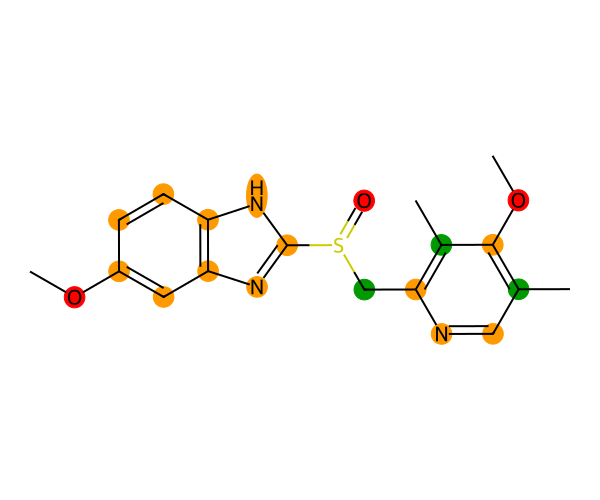

In [8]:
# Block 7: DEPLOYMENT BLOCK
# Screen any compound of your choosing against the trained
# AChE pharmacophore model

print("="*70)
print("PHARMACOPHORE-BASED VIRTUAL SCREENING TOOL")
print("="*70)
print("""
********************************************************************
*                                                                  *
*   IMPORTANT - READ BEFORE RUNNING                                *
*                                                                  *
*   The values currently in the INPUT SECTION below are           *
*   DEMONSTRATION VALUES ONLY.                                    *
*   They exist so this block runs successfully on first try.       *
*                                                                  *
*   TO SCREEN YOUR OWN COMPOUND:                                  *
*   1. Scroll to "STUDENT INPUT SECTION" below                    *
*   2. REPLACE new_compound_name with your compound's name        *
*   3. REPLACE new_compound_smiles with your compound's SMILES    *
*      (get this from PubChem, ChemSpider, or your literature      *
*      reference - search the compound name + "SMILES")           *
*   4. Do NOT change anything below                                *
*      "END OF INPUT SECTION"                                     *
*   5. Then run this cell again                                    *
*                                                                  *
*   No file upload is needed - all input is typed directly         *
*   into the Python variables below.                              *
*                                                                  *
*   REQUIREMENT: Blocks 1 through 4 must already have been run     *
*   successfully in this session, since this block reuses the      *
*   trained model, fingerprint function, and feature extractor      *
*   built in those earlier blocks.                                 *
*                                                                  *
********************************************************************
""")

# ============================================================
# STUDENT INPUT SECTION - EDIT EVERYTHING BELOW THIS LINE
# ============================================================

new_compound_name = "My_Test_Compound"          # <-- EDIT: type your compound's name

new_compound_smiles = "COc1ccc2[nH]c(S(=O)Cc3ncc(C)c(OC)c3C)nc2c1"
# <-- EDIT: replace this entire line with YOUR compound's SMILES
# (demonstration value above is Omeprazole - delete it and paste yours)

# ============================================================
# END OF INPUT SECTION - DO NOT EDIT ANYTHING BELOW THIS LINE
# ============================================================

print(f"\n{'='*70}")
print("CONFIRMING YOUR INPUT")
print(f"{'='*70}")
print(f"Compound name entered: {new_compound_name}")
print(f"SMILES entered: {new_compound_smiles}")
if new_compound_name == "My_Test_Compound":
    print("\n*** WARNING: You are still using the DEMONSTRATION value. ***")
    print("*** Edit the STUDENT INPUT SECTION above with your own data. ***")
print(f"{'='*70}")

mol_check = Chem.MolFromSmiles(new_compound_smiles)

if mol_check is None:
    print("\nERROR: Invalid SMILES. Check your SMILES string for typos.")
else:
    print("\nStep 1: Extracting pharmacophoric features...")
    new_features = extract_pharmacophore_features(new_compound_smiles)

    print(f"\nPharmacophoric features detected:")
    for feature_name, count in new_features.items():
        print(f"  {feature_name}: {count}")

    print("\nStep 2: Generating pharmacophore fingerprint...")
    new_fp = get_pharmacophore_fingerprint(new_compound_smiles)

    if new_fp is None:
        print("ERROR: Could not generate fingerprint for this molecule.")
    else:
        print("Fingerprint generated successfully")

        print("\nStep 3: Running prediction through neural network...")
        new_fp_reshaped = new_fp.reshape(1, -1)
        probability = model.predict(new_fp_reshaped, verbose=0)[0][0]

        print(f"\n{'='*70}")
        print(f"VIRTUAL SCREENING RESULT: {new_compound_name}")
        print(f"{'='*70}")
        print(f"Predicted probability of AChE activity: {probability:.3f}")

        if probability >= 0.7:
            interpretation = "HIGH likelihood of AChE activity - strong virtual hit"
        elif probability >= 0.5:
            interpretation = "MODERATE likelihood of AChE activity - possible hit"
        elif probability >= 0.3:
            interpretation = "LOW likelihood of AChE activity"
        else:
            interpretation = "VERY LOW likelihood of AChE activity"

        print(f"Interpretation: {interpretation}")

        print(f"\nComparison with the classical AChE pharmacophore pattern:")
        print(f"  Average Aromatic features in known actives: "
              f"{comparison.loc['Active (1)', 'PF_Aromatic']:.2f}")
        print(f"  This compound's Aromatic features: {new_features['Aromatic']}")
        print(f"  Average Hydrophobe features in known actives: "
              f"{comparison.loc['Active (1)', 'PF_Hydrophobe']:.2f}")
        print(f"  This compound's Hydrophobe features: {new_features['Hydrophobe']}")

        print(f"\nStep 4: Visualizing pharmacophoric features on this compound...")

        AllChem.Compute2DCoords(mol_check)
        features_display = feature_factory.GetFeaturesForMol(mol_check)

        highlight_atoms_new = {}
        highlight_colors_new = {}

        for feat in features_display:
            family = feat.GetFamily()
            if family in feature_colors:
                for atom_idx in feat.GetAtomIds():
                    highlight_atoms_new[atom_idx] = True
                    highlight_colors_new[atom_idx] = feature_colors[family]

        drawer_new = rdMolDraw2D.MolDraw2DCairo(600, 500)
        rdMolDraw2D.PrepareAndDrawMolecule(
            drawer_new, mol_check,
            highlightAtoms=list(highlight_atoms_new.keys()),
            highlightAtomColors=highlight_colors_new
        )
        drawer_new.FinishDrawing()

        with open(f'/content/{new_compound_name}_pharmacophore.png', 'wb') as f:
            f.write(drawer_new.GetDrawingText())

        img_new = Image.open(f'/content/{new_compound_name}_pharmacophore.png')

        print(f"\nColor legend: Blue=Donor, Red=Acceptor, Orange=Aromatic,")
        print(f"Green=Hydrophobe, Purple=PosIonizable, Teal=NegIonizable")

        print(f"\nREMINDER: This is a computational prediction based on")
        print(f"pharmacophore pattern similarity. Experimental validation")
        print(f"(enzyme inhibition assay) is required to confirm any result.")

        display(img_new)

Meaning of Block 7:

Purpose: A complete, self-contained pharmacophore-based virtual screening tool where a student inputs any compound's SMILES and receives a full analysis — detected pharmacophoric features, generated fingerprint, neural network prediction with plain-language interpretation, direct comparison against the known active-compound feature averages, and a visual, color-coded depiction of exactly where each pharmacophoric feature sits on their molecule.

What data comes IN: Student-typed compound name and SMILES. extract_pharmacophore_features, get_pharmacophore_fingerprint, model, feature_factory, feature_colors, comparison from all previous blocks.

What happens inside — line by line:

The warning banner and confirmation echo follow the identical safeguard pattern used throughout your entire series, with an explicit note that Blocks 1–4 must already have run in this session, since this tool reuses the trained model and helper functions built there rather than regenerating them.
Steps 1–3 reuse the exact same feature extraction, fingerprint generation, and prediction pipeline established in Blocks 2, 4, and 6 — ensuring the new compound is processed identically to every compound in the training and screening sets.
The four-tier interpretation scale (HIGH at ≥0.7, MODERATE at ≥0.5, LOW at ≥0.3, VERY LOW below) gives an intuitive, plain-language reading of the raw probability.
The direct comparison against comparison.loc['Active (1)', ...] — the same active-compound feature averages calculated back in Block 2 — lets a student immediately see whether their compound's aromatic and hydrophobic feature counts align with or diverge from the classical AChE pharmacophore pattern established from thousands of real ChEMBL compounds.
Step 4 regenerates the same color-coded 2D visualization technique from Block 3, now applied to the student's own molecule, making the abstract prediction visually concrete and interpretable.

What comes OUT: A complete virtual screening report for any compound a student chooses — pharmacophoric feature breakdown, predicted activity probability with interpretation, comparative context against known actives, and a color-coded visual depiction of the pharmacophore pattern on their specific molecule.